1. Imports

In [ ]:
from pathlib import Path
import os
import platform
import time

import numpy as np
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

2. Configuração (alvo **T030**: `temperature_C` — regressão; métricas MAE, RMSE, R²)

In [ ]:
def resolve_data_parquet() -> Path:
    """Repo root: data/Indian.... ; cwd em notebooks/: sobe um nível (evita ../data quebrado)."""
    name = Path("data") / "Indian_Weather_Dataset.parquet"
    for base in (Path.cwd(), Path.cwd().parent):
        p = (base / name).resolve()
        if p.is_file():
            return p
    raise FileNotFoundError(
        "Não encontrei Indian_Weather_Dataset.parquet em ./data/ nem ../data/. "
        "Coloque o Parquet em BigData/data/ e use cwd = raiz do repo ou pasta notebooks/."
    )


DATA_PATH = str(resolve_data_parquet())

# Mesmas frações que scripts/split_temporal.py (T021)
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

BATCH_SIZE = 8192
EPOCHS = 10
LR = 0.0001
# Sem early stopping (T033): percorrem-se sempre EPOCHS épocas completas.

TARGET = "temperature_C"

CAT_COLS = ["state", "city", "crops"]

# Numéricas de entrada: não incluir o alvo (evita fuga de rótulo).
NUM_COLS = [
    "lat","lon","humidity_pct","pressure_hPa",
    "dew_point_C","pressure_trend","solar_radiation_Wm2",
    "wind_speed_ms","cloud_cover_pct","hour","month",
    "wind_dir_sin","wind_dir_cos","et0_mm"
]

3. Ativações e perda (MSE — regressão)

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)


def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((yhat - y) ** 2))

4. Modelo (MLP — **T033**)

| # | Tipo | Dimensão (entrada → saída) | Ativação na saída |
|---|------|-----------------------------|-------------------|
| 1 | Linear + bias | `input_dim` → **64** | ReLU |
| 2 | Linear + bias | **64** → **32** | ReLU |
| 3 | Linear + bias | **32** → **1** | linear (regressão em `temperature_C`) |

`input_dim` = len(`NUM_COLS`) + one-hot(`state`, `city`, `crops`).

**Otimização:** SGD manual (um passo `backward` por batch), taxa `LR`, perda batch MSE alinhada à métrica global MSE no treino.

**Early stopping:** não aplicável neste notebook — treino fixo em `EPOCHS` épocas (registar abaixo tempo e hardware após o treino).

In [4]:
class MLP:
    def __init__(self, input_dim):
        scale = 0.01
        self.W1 = RNG.normal(size=(input_dim, 64)) * scale
        self.b1 = np.zeros((1, 64))

        self.W2 = RNG.normal(size=(64, 32)) * scale
        self.b2 = np.zeros((1, 32))

        self.W3 = RNG.normal(size=(32, 1)) * scale
        self.b3 = np.zeros((1, 1))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        self.out = self.z3  # saída linear (regressão)
        return self.out

    def backward(self, X, y, lr):
        n = X.shape[0]
        # Gradiente de mean((out - y)^2) em relação a z3 (idem out).
        dz3 = 2.0 * (self.out - y) / n
        db3 = np.sum(dz3, axis=0, keepdims=True)
        dW3 = self.a2.T @ dz3

        dz2 = (dz3 @ self.W3.T) * relu_grad(self.z2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dW2 = self.a1.T @ dz2

        dz1 = (dz2 @ self.W2.T) * relu_grad(self.z1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        dW1 = X.T @ dz1

        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

5. Dataset

In [5]:
def temporal_split_filters(dataset, train_frac: float, val_frac: float):
    """Split temporal alinhado a scripts/split_temporal.py (T021): ordena por datetime e corta por frações."""
    dt_tbl = dataset.to_table(columns=["datetime"])
    dt = dt_tbl.column(0).combine_chunks()
    if not pa.types.is_timestamp(dt.type):
        dt = pc.cast(dt, pa.timestamp("ms"))
    order = pc.sort_indices(dt)
    dt_sorted = pc.take(dt, order)
    n = len(dt_sorted)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    n_test = n - n_train - n_val
    if min(n_train, n_val, n_test) < 1:
        raise ValueError(f"Dataset demasiado pequeno para split 70/15/15: n={n}")
    cut_tv = dt_sorted[n_train]
    cut_vt = dt_sorted[n_train + n_val]
    train_filter = pc.field("datetime") < cut_tv
    val_filter = (pc.field("datetime") >= cut_tv) & (pc.field("datetime") < cut_vt)
    test_filter = pc.field("datetime") >= cut_vt
    meta = {"n": n, "n_train": n_train, "n_val": n_val, "n_test": n_test}
    return train_filter, val_filter, test_filter, meta


dataset = ds.dataset(DATA_PATH, format="parquet")
train_filter, val_filter, test_filter, SPLIT_META = temporal_split_filters(
    dataset, TRAIN_FRAC, VAL_FRAC
)
print(
    "Split T021:", SPLIT_META, "| train rows:",
    dataset.to_table(columns=["datetime"], filter=train_filter).num_rows,
)

Split T021: {'n': 46082160, 'n_train': 32257511, 'n_val': 6912324, 'n_test': 6912325} | train rows: 32257338


6. Categorias (one-hot simples)

In [6]:
def build_maps():
    maps = {}
    for col in CAT_COLS:
        vals = dataset.to_table(columns=[col])[col].to_pylist()
        maps[col] = {v:i for i,v in enumerate(set(vals))}
    return maps

cat_maps = build_maps()

KeyboardInterrupt: 

7. Normalização (treino)

In [ ]:
def get_stats():
    table = dataset.to_table(columns=NUM_COLS, filter=train_filter)
    if table.num_rows == 0:
        raise ValueError(
            "Treino vazio: train_filter não cobre nenhuma linha. Verifique DATA_PATH e o split temporal."
        )
    means, stds = [], []
    for col in NUM_COLS:
        arr = np.asarray(table[col], dtype=np.float64)
        m = np.nanmean(arr)
        s = np.nanstd(arr)
        if not np.isfinite(m):
            raise ValueError(f"Média não finita na coluna numérica '{col}' (treino).")
        stds.append(float(s) if s > 1e-12 else 1.0)
        means.append(float(m))
    return np.array(means), np.array(stds)


means, stds = get_stats()

8. Batch → NumPy

In [ ]:
def to_xy(batch):
    d = batch.to_pydict()

    Xn = np.stack(
        [np.asarray(d[c], dtype=np.float64) for c in NUM_COLS],
        axis=1,
    )
    Xn = (Xn - means) / stds
    Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)

    cats = []
    for c in CAT_COLS:
        idx = np.array([cat_maps[c].get(v, 0) for v in d[c]], dtype=np.int64)
        oh = np.zeros((len(idx), len(cat_maps[c])))
        oh[np.arange(len(idx), dtype=np.int64), idx] = 1
        cats.append(oh)

    X = np.concatenate([Xn] + cats, axis=1)
    y = np.nan_to_num(np.asarray(d[TARGET], dtype=np.float64), nan=0.0).reshape(-1, 1)

    return X.astype(np.float32), y.astype(np.float32)

9. Treino

In [ ]:
input_dim = len(NUM_COLS) + sum(len(cat_maps[c]) for c in CAT_COLS)
model = MLP(input_dim)

train_loss_hist = []

start = time.time()

for epoch in range(EPOCHS):
    losses = []

    scanner = dataset.scanner(
        columns=NUM_COLS + CAT_COLS + [TARGET],
        filter=train_filter,
        batch_size=BATCH_SIZE,
    )

    for batch in scanner.to_batches():
        X, y = to_xy(batch)
        if X.shape[0] == 0:
            continue

        pred = model.forward(X)
        loss = mse(y, pred)
        if not np.isfinite(loss):
            raise RuntimeError("Loss não finita; verifique dados e normalização.")

        model.backward(X, y, LR)
        losses.append(loss)

    if not losses:
        raise RuntimeError(
            "Nenhum batch de treino percorrido — train_filter ou DATA_PATH incorrectos, "
            "ou colunas em falta no Parquet."
        )
    train_loss = float(np.mean(losses))
    train_loss_hist.append(train_loss)

    print(f"Epoch {epoch+1} | mse={train_loss:.4f}")

elapsed_s = time.time() - start
print()
print("--- T033: tempo e hardware (registar na revisão da tarefa) ---")
print(f"Tempo de treino (aprox.): {elapsed_s:.1f} s ({elapsed_s / 60:.2f} min)")
print(f"SO: {platform.system()} {platform.release()} | máquina: {platform.machine()}")
print(f"Processador: {platform.processor() or 'n/d'}")
print(f"CPUs lógicos (os.cpu_count): {os.cpu_count()}")
print(f"NumPy: {np.__version__}")
try:
    _cfg = np.show_config(mode="dicts")
    _blas = _cfg["Build Dependencies"]["blas"]["name"]
    print(f"BLAS (build do wheel NumPy): {_blas}")
except Exception:
    print("BLAS: (detalhe indisponível nesta versão de NumPy)")

Epoch 1 | mse=15.1800
Epoch 2 | mse=1.0570
Epoch 3 | mse=0.3073

--- T033: tempo e hardware (registar na revisão da tarefa) ---
Tempo de treino (aprox.): 3806.9 s (63.45 min)
SO: Linux 6.6.87.2-microsoft-standard-WSL2 | máquina: x86_64
Processador: x86_64
CPUs lógicos (os.cpu_count): 16
NumPy: 1.22.4
BLAS: (detalhe indisponível nesta versão de NumPy)


10. Avaliação

In [ ]:
def evaluate(filt):
    """MAE, RMSE, R² no protocolo T030 (agregação streaming)."""
    scanner = dataset.scanner(
        columns=NUM_COLS + CAT_COLS + [TARGET],
        filter=filt,
        batch_size=BATCH_SIZE,
    )
    n = 0
    sum_y = 0.0
    sum_y2 = 0.0
    sse = 0.0
    sae = 0.0
    for batch in scanner.to_batches():
        X, y = to_xy(batch)
        p = model.forward(X)
        n += y.shape[0]
        sum_y += float(y.sum())
        sum_y2 += float((y**2).sum())
        sse += float(((p - y) ** 2).sum())
        sae += float(np.abs(p - y).sum())
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    mae = sae / n
    rmse = float(np.sqrt(sse / n))
    ss_tot = sum_y2 - (sum_y * sum_y) / n
    r2 = 1.0 - (sse / ss_tot) if ss_tot > 1e-9 else float("nan")
    return mae, rmse, r2


print("VAL  (MAE, RMSE, R2):", evaluate(val_filter))
print("TEST (MAE, RMSE, R2):", evaluate(test_filter))

VAL  (MAE, RMSE, R2): (0.4523283678605514, 0.6946817916797903, 0.9910906676214696)
TEST (MAE, RMSE, R2): (0.45286559148577943, 0.7093695725721109, 0.9909585911373676)


11. Gráfico

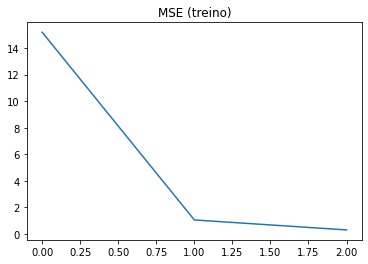

In [ ]:
plt.plot(train_loss_hist)
plt.title("MSE (treino)")
plt.show()